# README


**Project Title:**  

**Tutorial section: TT6L**

**Group04**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 30%          | 
| 2 | Student_ID2  | Student_Name1               | 20%          | 
| 3 | Student_ID3  | Student_Name1               | 10%          | 
| 4 | Student_ID4  | Student_Name1               | 40%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


In [502]:
import numpy as np
import pandas as pd
from numpy import nan as NA
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [503]:
netflix = pd.read_csv('netflix_titles.csv')
netflix.shape

(8807, 12)

In [504]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [505]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


### Data Cleaning

In [506]:
netflix = pd.read_csv('netflix_titles.csv')
print(netflix.shape)
netflix.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Handle missing data

In [507]:
null_rows = netflix.isnull().any(axis=1)
netflix[null_rows] #shows 3475 rows with missing data


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [508]:
netflix[null_rows].shape

(3475, 12)

In [509]:
netflix.isnull().sum() #check null value total

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [510]:
def null_values(netflix):
    
    #Fill director, cast and country with null value with 'Unknown'
    netflix['director'] = netflix['director'].fillna('Unknown')
    netflix['cast'] = netflix['cast'].fillna('Unknown')
    netflix['country'] = netflix['country'].fillna('Unknown')

    #Drop null value of date_added and duration
    netflix = netflix.dropna(subset = ['date_added'])
    netflix = netflix.dropna(subset = ['duration'])

    #Replace rating with most frequent category
    netflix["rating"] =  netflix["rating"].fillna(netflix["rating"].mode()[0]) 

    return netflix

#### Check on Data Type

In [511]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [512]:
def fix_datatypes(netflix):
    #Convert 'date_added' to datetime instead of string
    netflix['date_added'] = netflix['date_added'].str.strip() # to clean the extra spaces
    netflix['date_added'] = pd.to_datetime(netflix['date_added'])

    return netflix

#### Check Duplicated Data

In [513]:
netflix.duplicated().sum()

np.int64(0)

#### Clean Text

In [514]:
def clean_text(netflix):

    netflix['type'] = netflix['type'].str.strip().str.upper()
    
    #Only one country per show
    netflix['country'] = netflix['country'].str.split(',').str[0]

    return netflix

#### Divide Duration into it type and value

In [515]:
def divide_duration(netflix):

    #Divide duration into type and value
    netflix[['duration_value', 'duration_type']] = netflix['duration'].str.split(' ', n=1, expand=True)
    netflix['duration_value'] = netflix['duration_value'].astype(int)

    return netflix

### Create Cleaning Pipepline

In [516]:
clean_netflix = (
    netflix
    .pipe(null_values)
    .pipe(fix_datatypes)
    .pipe(clean_text)
    .pipe(divide_duration)

)

In [517]:

clean_netflix.to_csv('netflix_cleaned.csv', index = False)

## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


## 7. Performance Evaluation and Enhancement (if applicable)

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


## Regression
- Predict the release year of a Netflix title using its genre, rating, duration and type


In [518]:
df = pd.read_csv('netflix_cleaned.csv', encoding='latin1')

In [519]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [520]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [521]:
X = df[['type', 'rating', 'listed_in', 'duration_value']]
y = df[['release_year']]

In [522]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
type_cat = df["type"].values
type_cat_encoded = encoder.fit_transform(type_cat.astype('str'))
type_cat_encoded
df['type_cat_encoded'] = type_cat_encoded

In [523]:
#one-hot encoding for 'rating' & 'listed_in'
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)
rating_listed_cat = encoder.fit_transform(df[['rating', 'listed_in']])
rating_listed_cat_encoded = pd.DataFrame(rating_listed_cat, columns=encoder.get_feature_names_out(['rating', 'listed_in']))
rating_listed_cat_encoded.head()

,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [524]:
#combine type_encoded with rating_listed_encoded and duration_value
X = pd.concat([df[['type_cat_encoded', 'duration_value']],rating_listed_cat_encoded],axis=1)
y = df['release_year']

In [525]:
X.head(15)

,type_cat_encoded,duration_value,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,90,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,91,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,125,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,9,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0,104,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [526]:
y.head()

0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64

In [527]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [528]:
# check shapes after splitting
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(6595, 529)
(6595,)
(2199, 529)
(2199,)


In [529]:
from sklearn.linear_model import LinearRegression

In [530]:
model = LinearRegression().fit(X_train, y_train)

In [531]:
y_pred = model.predict(X_test)

In [532]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [533]:
#get r2 coefficient
r2 = model.score(X_test, y_test)
print("R² score:", r2)

#get MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#get MSE
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MSE:", mse)

R² score: 0.34949253597067576
MAE: 4.270099391465719
MSE: 6.912713420448941


In [534]:
#predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

      Actual    Predicted
3092    2019  2018.454681
4079    2018  2017.306728
4892    2015  2016.093330
4589    2018  2018.108021
5317    2017  2014.146904


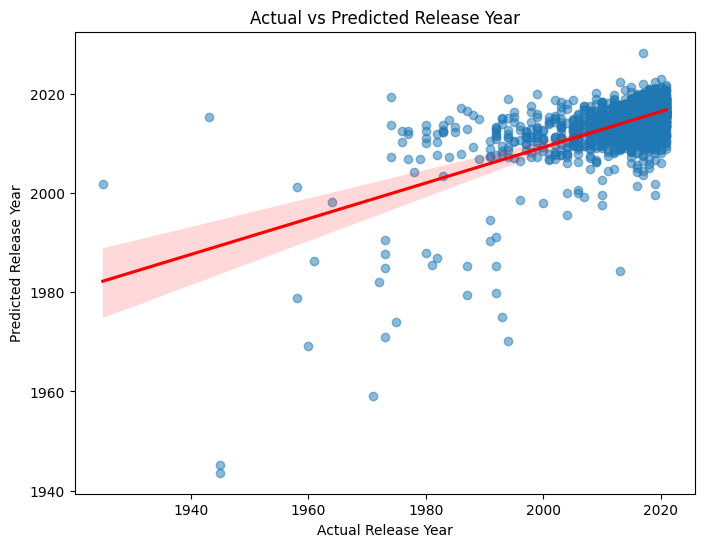

In [535]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.xlabel("Actual Release Year")
plt.ylabel("Predicted Release Year")
plt.title("Actual vs Predicted Release Year")

plt.show()

Scatter plot shows the relationship between actual and predicted release years generated by the Linear Regression model. The model shows a positive trend indicating that it demonstrates better predictive performance for titles released in the year 2000-2020. However, it has a harder time capturing patterns from older titles due to limited number of older titles present in the dataset.

## Clustering
- Can netflix content be grouped into distinct clusters based on genre, duration, rating and release period?

In [536]:
from sklearn.preprocessing import StandardScaler  # For scaling dataset
from sklearn.cluster import KMeans, AgglomerativeClustering, AffinityPropagation 

netflix = pd.read_csv("netflix_cleaned.csv")

We split the data into 2 categories which are Movies and TV Shows due to the different units of duration value.

### Movies

In [537]:
netflix1 = netflix[netflix['type'] == 'MOVIE']
netflix_movies = netflix1[['release_year','listed_in','duration_value','rating']] # extract features of interest
netflix_movies.head()

,release_year,listed_in,duration_value,rating
0,2020,Documentaries,90,PG-13
6,2021,Children & Family Movies,91,PG
7,1993,"Dramas, Independent Movies, International Movies",125,TV-MA
9,2021,"Comedies, Dramas",104,PG-13
12,2021,"Dramas, International Movies",127,TV-MA


Step 1: Preprocessing (Handling One-to-Many Genres & Ratings)
- Split genre strings into their own row

In [538]:
netflix_movies['listed_in'] = netflix_movies['listed_in'].str.split(", ")
netflix_movies = netflix_movies.explode('listed_in')
netflix_movies.head()

,release_year,listed_in,duration_value,rating
0,2020,Documentaries,90,PG-13
6,2021,Children & Family Movies,91,PG
7,1993,Dramas,125,TV-MA
7,1993,Independent Movies,125,TV-MA
7,1993,International Movies,125,TV-MA


- convert the genre and rating into numerical data

In [539]:
from sklearn.preprocessing import LabelEncoder

genre_encoder = LabelEncoder()
genre_cat = netflix_movies['listed_in'].values
genre_cat_encoded = genre_encoder.fit_transform(genre_cat.astype('str'))
genre_cat_encoded

array([ 6,  2,  7, ...,  7, 11, 14], shape=(13187,))

In [540]:
rating_encoder = LabelEncoder()
rating_cat = netflix_movies['rating'].values
rating_cat_encoded = rating_encoder.fit_transform(rating_cat.astype('str'))
rating_cat_encoded

array([4, 3, 8, ..., 6, 6, 6], shape=(13187,))

In [541]:
netflix_movies['listed_in'] = genre_encoder.fit_transform(netflix_movies['listed_in'])
netflix_movies['rating'] = rating_encoder.fit_transform(netflix_movies['rating'])
netflix_movies.head()

,release_year,listed_in,duration_value,rating
0,2020,6,90,4
6,2021,2,91,3
7,1993,7,125,8
7,1993,10,125,8
7,1993,11,125,8


Step 2: Feature Scaling
- z-normalization by removing the mean followed by scaling to unit variance

In [542]:
ss = StandardScaler()
X = ss.fit_transform(netflix_movies)
print(netflix_movies)
print(X) 

      release_year  listed_in  duration_value  rating
0             2020          6              90       4
6             2021          2              91       3
7             1993          7             125       8
7             1993         10             125       8
7             1993         11             125       8
...            ...        ...             ...     ...
8792          2006          2              88       3
8792          2006          4              88       3
8793          2015          7             111       6
8793          2015         11             111       6
8793          2015         14             111       6

[13187 rows x 4 columns]
[[ 0.71424564 -0.52802406 -0.50588879 -1.35921488]
 [ 0.81322583 -1.33388637 -0.46931488 -1.87902134]
 [-1.95821958 -0.32655848  0.77419828  0.72001099]
 ...
 [ 0.21934467 -0.32655848  0.26216345 -0.31960194]
 [ 0.21934467  0.47930383  0.26216345 -0.31960194]
 [ 0.21934467  1.08370056  0.26216345 -0.31960194]]


Step 3: Elbow Method
- The Elbow Method is used to find the optimal number of clusters (k) in K-Means by analyzing how the clustering performance changes with different k values (GeeksforGeeks, 2019). 

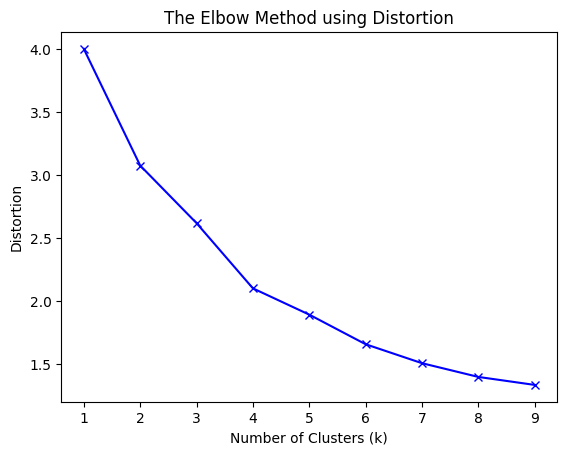

In [543]:
from sklearn import metrics
from scipy.spatial.distance import cdist

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    inertias.append(kmeanModel.inertia_)
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

From the results, the optimal number of clusters is k=2.

Step 4: K-Means Clustering
- 2 clusters based on the results from the Elbow Method

In [544]:
model = KMeans(2, verbose=0, n_init='auto')
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Step 5: View K-Means Function Properties 
1. `cluster_centers_` contains the centers of the two clusters found thru k-means algorithm. Each of these centers have 4 values. 

In [545]:
print(model.cluster_centers_.shape)
model.cluster_centers_

(2, 4)


array([[ 0.38479152,  0.19386786, -0.3446559 ,  0.60742712],
       [-0.52866406, -0.26635455,  0.47352184, -0.83454253]])

2. `labels_` contains the cluster labels for each data point. Since we set k=2, we get either labels 0 or 1 assigned to the data points. 

In [546]:
print(model.labels_.shape)
model.labels_

(13187,)


array([1, 1, 1, ..., 1, 0, 0], shape=(13187,), dtype=int32)

3. `inertia_` is the sum of squared distances (SSD) of samples to their cluster centers.

In [547]:
model.inertia_

40547.37040293471

4. `n_iter_` is the number of iterations k-means took to arrive at stable cluster centers.

In [548]:
model.n_iter_

14

Step 6: Plot K-Means Clustering Graph
- Add labels as a new column into the dataframe

In [549]:
netflix_movies['kmeans'] = model.labels_
netflix_movies

,release_year,listed_in,duration_value,rating,kmeans
0,2020,6,90,4,1
6,2021,2,91,3,1
7,1993,7,125,8,1
7,1993,10,125,8,1
7,1993,11,125,8,1
...,...,...,...,...,...
8792,2006,2,88,3,1
8792,2006,4,88,3,1
8793,2015,7,111,6,1
8793,2015,11,111,6,0


- Plot the K-Means Clustering Graph for Netflix Movies

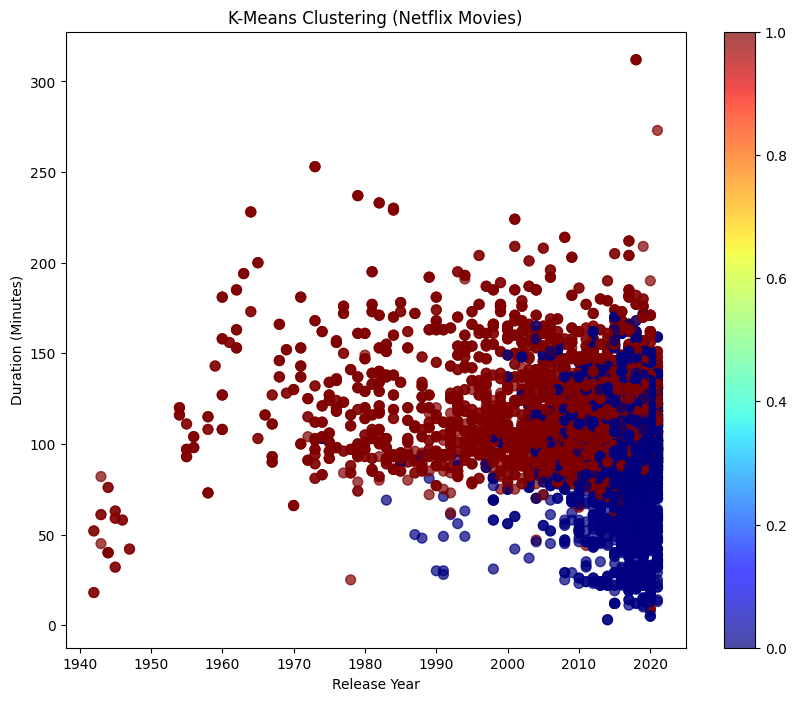

In [550]:
v1 = netflix_movies['release_year']
v2 = netflix_movies['duration_value']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=model.labels_, s=50, cmap='jet', alpha=0.7)
ax.set_title('K-Means Clustering (Netflix Movies)')
ax.set_xlabel('Release Year')
ax.set_ylabel('Duration (Minutes)')
plt.colorbar(scatter)
plt.show()

Now, we do the k-means clustering for Netflix TV Shows.

### TV Shows

In [551]:
netflix2 = netflix[netflix['type'] == 'TV SHOW']
netflix_tvshow = netflix2[['release_year','listed_in','duration_value','rating']]
netflix_tvshow.head()

,release_year,listed_in,duration_value,rating
1,2021,"International TV Shows, TV Dramas, TV Mysteries",2,TV-MA
2,2021,"Crime TV Shows, International TV Shows, TV Act...",1,TV-MA
3,2021,"Docuseries, Reality TV",1,TV-MA
4,2021,"International TV Shows, Romantic TV Shows, TV ...",2,TV-MA
5,2021,"TV Dramas, TV Horror, TV Mysteries",1,TV-MA


Step 1: Preprocessing (Handling One-to-Many Genres & Ratings)
- Split genre strings into their own row
- convert the genre and rating into numerical data

In [552]:
netflix_tvshow['listed_in'] = netflix_tvshow['listed_in'].str.split(", ")
netflix_tvshow = netflix_tvshow.explode('listed_in')

genre_encoder = LabelEncoder()
genre_cat = netflix_tvshow['listed_in'].values
genre_cat_encoded = genre_encoder.fit_transform(genre_cat.astype('str'))
genre_cat_encoded

rating_encoder = LabelEncoder()
rating_cat = netflix_tvshow['rating'].values
rating_cat_encoded = rating_encoder.fit_transform(rating_cat.astype('str'))
rating_cat_encoded

netflix_tvshow['listed_in'] = genre_encoder.fit_transform(netflix_tvshow['listed_in'])
netflix_tvshow['rating'] = rating_encoder.fit_transform(netflix_tvshow['rating'])
netflix_tvshow.head()

,release_year,listed_in,duration_value,rating
1,2021,5,2,4
1,2021,15,2,4
1,2021,17,2,4
2,2021,3,1,4
2,2021,5,1,4


Step 2: Feature Scaling
- z-normalization by removing the mean followed by scaling to unit variance

In [553]:
ss = StandardScaler()
Y = ss.fit_transform(netflix_tvshow)
print(netflix_tvshow)
print(Y) 

      release_year  listed_in  duration_value  rating
1             2021          5               2       4
1             2021         15               2       4
1             2021         17               2       4
2             2021          3               1       4
2             2021          5               1       4
...            ...        ...             ...     ...
8787          2012          9               1       5
8787          2012         15               1       5
8790          2018          6               2       7
8790          2018          7               2       7
8790          2018         14               2       7

[6113 rows x 4 columns]
[[ 0.82237879 -0.66318817  0.19034517  0.19633506]
 [ 0.82237879  1.26934558  0.19034517  0.19633506]
 [ 0.82237879  1.65585233  0.19034517  0.19633506]
 ...
 [ 0.23566007 -0.4699348   0.19034517  2.36929137]
 [ 0.23566007 -0.27668142  0.19034517  2.36929137]
 [ 0.23566007  1.0760922   0.19034517  2.36929137]]


Step 3: Elbow Method
- The Elbow Method is used to find the optimal number of clusters (k) in K-Means by analyzing how the clustering performance changes with different k values (GeeksforGeeks, 2019).

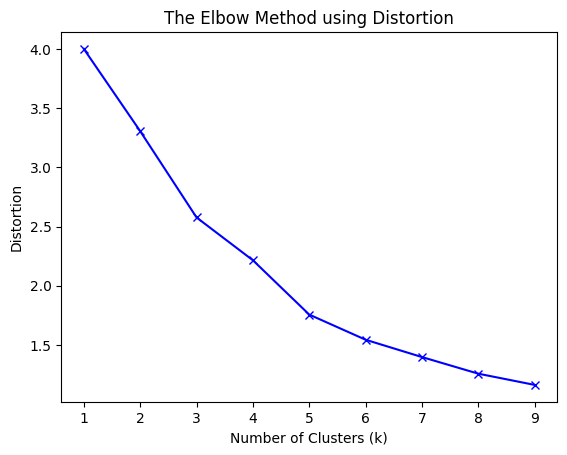

In [554]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(Y)
    distortions.append(sum(np.min(cdist(Y, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / Y.shape[0])
    inertias.append(kmeanModel.inertia_)
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

From the results, the optimal number of clusters can be either 2 or 3. We will take k=3.

Step 4: K-Means Clustering
- 3 clusters based on the results from the Elbow Method

In [555]:
model = KMeans(3, verbose=0, n_init=10)
model.fit(Y)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Step 5: View K-Means Function Properties 
1. `cluster_centers_` contains the centers of the two clusters found thru k-means algorithm. Each of these centers have 4 values. 

In [556]:
print(model.cluster_centers_.shape)
model.cluster_centers_

(3, 4)


array([[ 0.13275582,  1.10607357, -0.15875704, -0.18444   ],
       [ 0.0122726 , -0.70003163, -0.22879309,  0.13142255],
       [-0.86366552,  0.39004272,  3.05735168, -0.20394637]])

2. `labels_` contains the cluster labels for each data point. Since we set k=2, we get either labels 0 or 1 assigned to the data points. 

In [557]:
print(model.labels_.shape)
model.labels_

(6113,)


array([1, 0, 0, ..., 1, 1, 0], shape=(6113,), dtype=int32)

3. `inertia_` is the sum of squared distances (SSD) of samples to their cluster centers.

In [558]:
model.inertia_

15748.990811816013

4. `n_iter_` is the number of iterations k-means took to arrive at stable cluster centers.

In [559]:
model.n_iter_

8

Step 6: Plot K-Means Clustering Graph
- Add labels as a new column into the dataframe

In [560]:
netflix_tvshow['kmeans'] = model.labels_
netflix_tvshow

,release_year,listed_in,duration_value,rating,kmeans
1,2021,5,2,4,1
1,2021,15,2,4,0
1,2021,17,2,4,0
2,2021,3,1,4,1
2,2021,5,1,4,1
...,...,...,...,...,...
8787,2012,9,1,5,1
8787,2012,15,1,5,0
8790,2018,6,2,7,1
8790,2018,7,2,7,1


- Plot the K-Means Clustering Graph for Netflix Movies

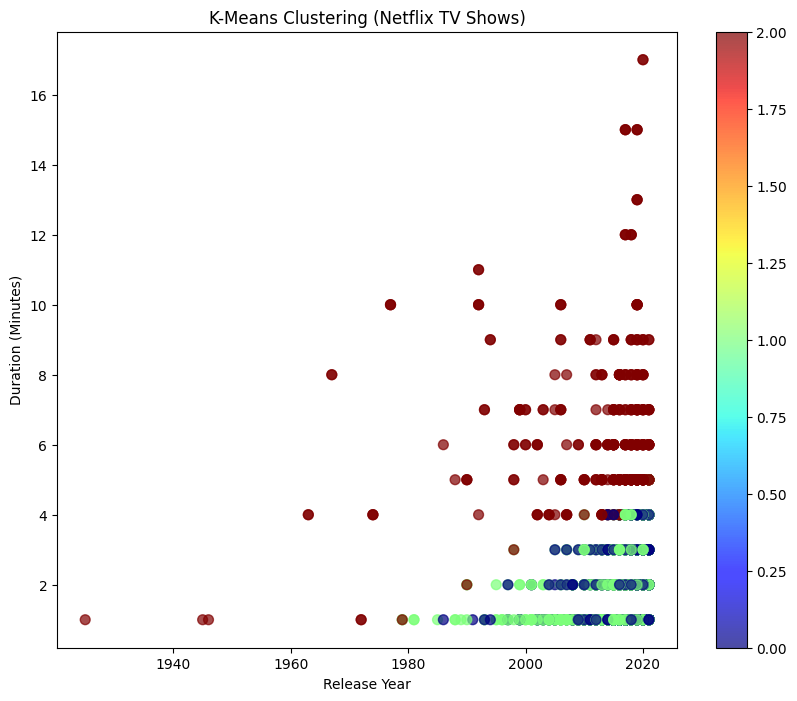

In [561]:
v1 = netflix_tvshow['release_year']
v2 = netflix_tvshow['duration_value']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=model.labels_, s=50, cmap='jet', alpha=0.7)
ax.set_title('K-Means Clustering (Netflix TV Shows)')
ax.set_xlabel('Release Year')
ax.set_ylabel('Duration (Minutes)')
plt.colorbar(scatter)
plt.show()

## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


### Regression
1. The Linear Regression model achieved an R² score of 0.349 indicating that approximately 34.9% of the variation in release year can be explained by the chosen variables.
2. This model also has a MAE of 4.27 meaning that predicted release years differ from actual release years by an average of 4 years.
3. It captures a better prediction from titles released in the year 2000-2020 compared to movies/TV shows released prior to 2000.

### Clustering
We split the data into 2 categories which are Movies and TV Shows due to the different units of duration value.

#### Movies
The Netflix movies are divided optimally into 2 clusters based on the elbow method analysis. The K-Means clustering graph illustrates a clear chronological split between these two groups: Cluster 0 (the red cluster) spans from 1940 until approximately 2010, after which Cluster 1 (the blue cluster) heavily dominates from 2010 to 2021.

- Cluster 1 (Blue Cluster) - Modern and Standardized 
This cluster exhibits a highly standardized duration range, with the vast majority of movies falling strictly between 80 and 120 minutes. This aligns with how recent, modern movies are mostly uniform-length (runtimes of around 1.5 to 2 hours) which fits with the results of our graph. Due to the large volume of movies that share the same feature, it is grouped into its own cluster. 

- Cluster 0 (Red Cluster) - Vintage and Irregular
This cluster leans random and more spread out than Cluster 1. The release year range of this cluster starts as early as 1940s up until 2010. From this, we draw the conclusion that this cluster has more vintage, dated movies. The spread of the dots are also far and wide which causes our inertia to be greater. The duration of these movies are not uniform and are more random ranging from unusually short movies under 50 minutes to as long as over 300 minutes.

In conclusion, the Netflix movies are divided into 2 clusters in which we can categorise as "Modern and Standardized" and "Vintage and Irregular". While the multidimensional clustering incorporated genre and rating data, the primary factors visibling affecting the distribution are the film's release year and duration.

#### TV Shows
The Netflix TV shows are divided optimally into 3 clusters based on the elbow method analysis. The K-Means clustering graph illustrates a clear chronological split between these three groups: Cluster 0 (the red cluster) spans from before 1940 until 2021, after which Cluster 1 (the blue cluster) and Cluster 2 (the light green cluster) heavily dominates from the 2000s.

- Cluster 2 (Light Green Cluster) - Modern and Short Run Shows
This cluster mostly consists of TV shows that has 1 season. Although the majority of the TV shows aired afer the 2000s, this cluster holds shows from 1980-2000 too. Because the multi-dimensional algorithm factoreed in genre and rating features, it split these TV shows into two separate but similar profiles (Cluster 1 and Cluster 2) even though their release years and runtimes look visually similar on a 2D plane.

- Cluster 1 (Blue Cluster) - Modern and Short Run Shows 
This cluster is similar to that of Cluster 2 (light green cluster). However, the difference is that this cluster mainly has TV shows with more than 1 season. However, both Cluster 2 and Cluster 1 have similar short runs in which the shows in these clusters dont exceed 4 seasons. 

- Cluster 0 (Red Cluster) - Vintage and Long Running
This cluster ranges all the way back to the 1920s, capturing older, classic television programs. Simultaneously, it extends vertically to capture modern long-running programs that managed to survive for 5 to over 17 seasons. The algorithm grouped these together because their historical background or exceptional longevity distances them mathematically from mainstream modern entries.

In conclusion, the Netflix TV shows are divided into 3 clusters in which we can categorise two of them as "Modern and Short Run Shows" and the final one as "Vintage and Long Running". While the multidimensional clustering incorporated genre and rating data, the primary factors visibling affecting the distribution are the film's release year and duration. However, the genre and rating data is what causes the difference between the two "Modern and Short Run Shows" clusters. 


Finally we answer our analytical question: __Can netflix content be grouped into distinct clusters based on genre, duration, rating and release period?__
Yes, Netflix content can be grouped into distinct clusters based on genre, duration, rating, and release period. We get 2 clusters for Netflix movies and 3 clusters for Netflix TV shows.

## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


### Regression
- The limitiations I experienced is that the model has a more accurate prediction for titles released in the year 2000-2020. This is mainly because the dataset lacks titles that were released prior to 2000 which can affect the model's accuracy. The best step to improve my model is to remove the outliers which are movie/TV shows that were released prior to the 2000s. This can reduce my errors significantly and give me a better R² score.  

## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



GeeksforGeeks. (2019, June 6). Elbow Method for optimal value of k in KMeans. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime